# Courtship Song Analysis

Determine which wing is singing and classify song type (pulse vs sine)


In [1]:
import sys
from pathlib import Path

# Add project root to Python path FIRST to ensure our modules take priority
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    print(f"Added {project_root} to Python path")
elif sys.path.index(str(project_root)) != 0:
    # Move to front if it exists but isn't first
    sys.path.remove(str(project_root))
    sys.path.insert(0, str(project_root))
    print(f"Moved {project_root} to front of Python path")

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ['MUJOCO_GL'] = 'egl'
os.environ['PYOPENGL_PLATFORM'] = 'egl'
os.environ["XLA_FLAGS"] = "--xla_gpu_triton_gemm_any=True"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU 1

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
from scipy import signal as sig
from scipy.signal import hilbert, find_peaks, savgol_filter
from scipy.stats import median_abs_deviation
import utils.io_dict_to_hdf5 as ioh5

import jax.numpy as jnp
import mujoco
from tqdm.auto import tqdm
import mediapy as media

# Clean figure style
mpl.rcParams.update({
    'pdf.fonttype': 42,
    'pdf.use14corefonts': True,
    'font.family': 'sans-serif',
    'axes.spines.right': False,
    'axes.spines.top': False,
})


Added /home/eabe/Research/MyRepos/3d_tracking_dataset to Python path


In [2]:
def make_videos(
    mj_model,
    mj_data,
    qposes_rollout,
    scene_option,
    camera="track1",
    height=512,
    width=512,
    kp_data=None,
    mocap_indices=None,
    kp_anchor_idx=None,
    model_anchor_site_id=None,
):
    """
    Make a video of the rollout and reference superimposed.
    
    Args:
        kp_data: Optional (T, N_kp, 3) keypoint positions to overlay as mocap bodies.
        mocap_indices: Optional dict mapping keypoint index to mocap ID (from get_aligned_mocap_indices).
        kp_anchor_idx: Index of anchor keypoint (e.g. Scutellum) in kp_data for alignment.
        model_anchor_site_id: MuJoCo site ID of the corresponding anchor site on the body model.
    """
    frames = []
    with mujoco.Renderer(mj_model, height=height, width=width) as renderer:
        for t in tqdm(range(len(qposes_rollout))):
            mj_data.qpos = qposes_rollout[t]
            mujoco.mj_forward(mj_model, mj_data)
            
            # Update mocap body positions for keypoint overlay
            if kp_data is not None and mocap_indices is not None:
                # Compute offset to align kp anchor to model anchor
                offset = np.zeros(3)
                if kp_anchor_idx is not None and model_anchor_site_id is not None:
                    model_anchor_pos = mj_data.site_xpos[model_anchor_site_id]
                    kp_anchor_pos = kp_data[t, kp_anchor_idx, :]
                    offset = model_anchor_pos - kp_anchor_pos
                
                for kp_idx, mocap_id in mocap_indices.items():
                    mj_data.mocap_pos[mocap_id] = kp_data[t, kp_idx, :] + offset
                    mj_data.mocap_quat[mocap_id] = [1, 0, 0, 0]
            
            renderer.update_scene(
                mj_data, camera=f"{camera}", scene_option=scene_option
            )
            renderer.scene.flags[mujoco.mjtRndFlag.mjRND_SHADOW] = False
            pixels = renderer.render()
            frames.append(pixels)
    return frames

In [3]:
FS = 800  # Hz capture rate

# Egocentric keypoint indices (into xpos_egocentric, T x 50 x 3)
KP_SCUTELLUM = 0
KP_WINGL_BASE = 1
KP_WINGR_BASE = 2
KP_ANTENNA_BASE = 3
KP_WINGL_V12 = 6
KP_WINGL_V13 = 7
KP_WINGR_V12 = 8
KP_WINGR_V13 = 9

# qpos wing joint indices
QPOS_WING_YAW_L = 7
QPOS_WING_ROLL_L = 8
QPOS_WING_PITCH_L = 9
QPOS_WING_YAW_R = 10
QPOS_WING_ROLL_R = 11
QPOS_WING_PITCH_R = 12

In [4]:
h5_path = '/data2/users/eabe/datasets/Johnson_lab/courtship/Data_analysis/analysis/v1/ik_output_combined_v1_courtship.h5'
stac_data = ioh5.load(h5_path, enable_jax=False)

n_bouts = len(np.asarray(stac_data['info']['clip_lengths']))
clip_lengths = np.asarray(stac_data['info']['clip_lengths'])
print(f"Loaded {n_bouts} bouts, clip lengths: {clip_lengths}")

# Get keypoint and joint names (ioh5.load returns these as lists already)
kp_names = stac_data['info']['site_names_egocentric']
qpos_names = stac_data['info']['names_qpos']

# Handle both dict-with-int-keys and list formats
if isinstance(kp_names, dict):
    kp_names = [kp_names[k] for k in sorted(kp_names.keys(), key=lambda x: int(x))]
if isinstance(qpos_names, dict):
    qpos_names = [qpos_names[k] for k in sorted(qpos_names.keys(), key=lambda x: int(x))]

print(f"\nWing qpos names: {[qpos_names[i] for i in range(7, 13)]}")
print(f"Wing kp names: {[kp_names[i] for i in [KP_WINGL_BASE, KP_WINGR_BASE, KP_WINGL_V12, KP_WINGL_V13, KP_WINGR_V12, KP_WINGR_V13]]}")

Loaded 203 bouts, clip lengths: [ 512  567 1088  393  788 1054 1125 1214  753  938 1740  654 1024  934
 1173  545 1412  820  962  394 1159  934 1392  664  822  428  747 1579
 2006  513 1297  812  553  279 2390  506  294  267  318 1085  846  526
  666  959  703  622  500  703  409  839  715  774 2390  500  703  294
  409  318 1083  832  608  396 1505  765  308  536  291  611  660  240
  400 1038  422  609  437  293  775  471  617  693  913  744  425  293
  981  460  581  970  497  478  494  299  302  658  652 2186  239  455
  662  300  339  438  624  735  747  613  890  509  439  821  677  389
  524  336  974  449  958  694 1074  713 1223  953  616 1563 1796  386
  591  377  304  403  805 1203  841 1011  444  499  643  725  693  822
 1221  663  651  286 2018  777  568 2423  259  889  785  228 2448  336
  173  582  664  593 1175  341 1118  558 1597  274  339  643  390 1318
  826  628  974  197  353  206  765  345  858  676  331  605  226  892
  493  595  775  270  351  357  434  610  192

## Quick look at wing data

bout_056: xpos_egocentric (409, 50, 3), qpos (409, 93)


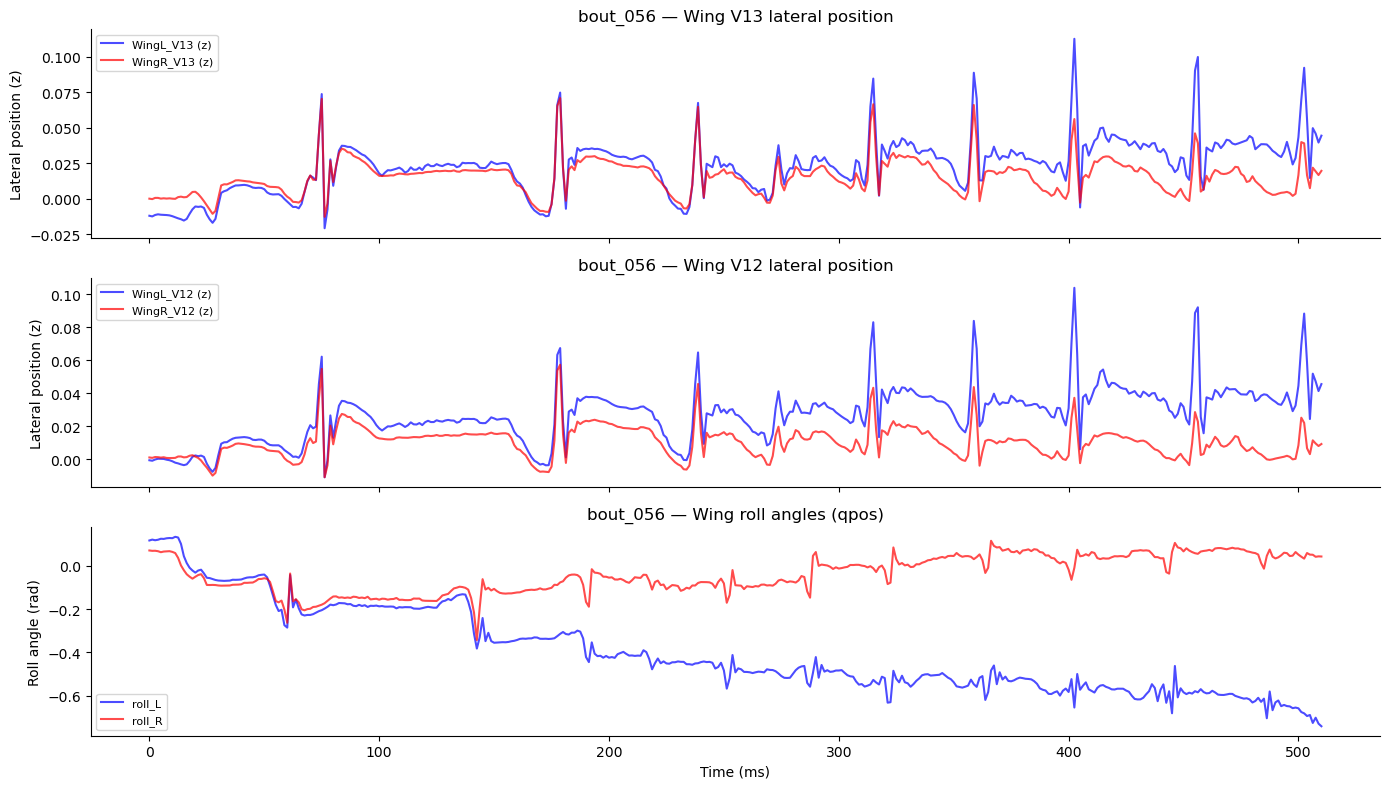

In [5]:
bout = 56
bd = stac_data[f'bout_{bout:03d}']
xpos_ego = np.asarray(bd['xpos_egocentric'])
qpos = np.asarray(bd['qpos'])
print(f"bout_{bout:03d}: xpos_egocentric {xpos_ego.shape}, qpos {qpos.shape}")

# Plot wing V12/V13 positions (z-component shows extension nicely)
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
t_ms = np.arange(xpos_ego.shape[0]) / FS * 1000

ax = axes[0]
ax.plot(t_ms, xpos_ego[:, KP_WINGL_V13, 2], 'b-', alpha=0.7, label='WingL_V13 (z)')
ax.plot(t_ms, xpos_ego[:, KP_WINGR_V13, 2], 'r-', alpha=0.7, label='WingR_V13 (z)')
ax.set_ylabel('Lateral position (z)')
ax.legend(fontsize=8)
ax.set_title(f'bout_{bout:03d} — Wing V13 lateral position')

ax = axes[1]
ax.plot(t_ms, xpos_ego[:, KP_WINGL_V12, 2], 'b-', alpha=0.7, label='WingL_V12 (z)')
ax.plot(t_ms, xpos_ego[:, KP_WINGR_V12, 2], 'r-', alpha=0.7, label='WingR_V12 (z)')
ax.set_ylabel('Lateral position (z)')
ax.legend(fontsize=8)
ax.set_title(f'bout_{bout:03d} — Wing V12 lateral position')

ax = axes[2]
ax.plot(t_ms, qpos[:, QPOS_WING_ROLL_L], 'b-', alpha=0.7, label='roll_L')
ax.plot(t_ms, qpos[:, QPOS_WING_ROLL_R], 'r-', alpha=0.7, label='roll_R')
ax.set_ylabel('Roll angle (rad)')
ax.set_xlabel('Time (ms)')
ax.legend(fontsize=8)
ax.set_title(f'bout_{bout:03d} — Wing roll angles (qpos)')

plt.tight_layout()
plt.show()

In [16]:
from utils.add_aligned_keypoint_sites import add_aligned_mocap_bodies, get_aligned_mocap_indices

clip_lengths = jnp.asarray(stac_data['info']['clip_lengths'])
skeleton_path = project_root / 'data' / 'fly50.json'
flybody_path = project_root.parent / 'fruitfly_body_models/fruitfly_v1' / 'fruitfly_v1_free.xml'
floor_path = project_root.parent / 'fruitfly_body_models/fruitfly_v2.1/floor.xml' # Path(cfg.anatomy.arena_path) #

bout = 56# np.argmax(clip_lengths)
spec = mujoco.MjSpec().from_file(flybody_path.as_posix())
floor_spec = mujoco.MjSpec().from_file(floor_path.as_posix())
spawn_frame = floor_spec.worldbody.add_frame(
                pos=[0,0,0],
                quat=[1,0,0,0],
            )
spawn_body = spawn_frame.attach_body(spec.body("thorax"), "", suffix='_fly')
use_interp = False
if not use_interp:
    end_eff_idxs = jnp.asarray([n for n, name in enumerate(stac_data['info']['names_xpos']) if 'claw' in name])
    floor_z_all = []
    for bout_temp in range(len(clip_lengths)):
        end_z = stac_data[f'bout_{bout_temp:03d}']['xpos'][:, end_eff_idxs, 2]
        floor_z = np.mean(np.quantile(end_z, [0.05], axis=0))
        floor_z_all.append(floor_z)
    floor_z_all = np.array(floor_z_all)
    floor_spec.geom('floor').pos[2] = np.mean(floor_z_all)

# Add mocap bodies for keypoint overlay
kp_names = stac_data['info'].get('kp_names', stac_data[f'bout_{bout:03d}'].get('kp_names', None))
if kp_names is not None:
    floor_spec = add_aligned_mocap_bodies(floor_spec, kp_names, color_coded=True, prefix='aligned_')

mj_model = floor_spec.compile()
mj_data = mujoco.MjData(mj_model)

# Get mocap indices for keypoint visualization
mocap_indices = None
bout_kp_data = None
kp_anchor_idx = None
model_anchor_site_id = None

if kp_names is not None:
    mocap_indices = get_aligned_mocap_indices(mj_model, kp_names, prefix='aligned_')
    bout_kp_data = stac_data[f'bout_{bout:03d}'].get('kp_data', None)
    if bout_kp_data is not None:
        bout_kp_data = np.asarray(bout_kp_data)
        # Reshape from (T, n_kp*3) to (T, n_kp, 3) if stored flat
        if bout_kp_data.ndim == 2 and bout_kp_data.shape[1] == len(kp_names) * 3:
            bout_kp_data = bout_kp_data.reshape(bout_kp_data.shape[0], len(kp_names), 3)
        print(f"Keypoint overlay enabled: {len(kp_names)} keypoints, kp_data shape: {bout_kp_data.shape}")

        # Find Scutellum anchor for alignment
        if 'Scutellum' in kp_names:
            kp_anchor_idx = kp_names.index('Scutellum')
            try:
                model_anchor_site_id = mujoco.mj_name2id(
                    mj_model, mujoco.mjtObj.mjOBJ_SITE, 'tracking[Scutellum]_fly')
                print(f"Scutellum alignment: kp index={kp_anchor_idx}, site id={model_anchor_site_id}")
            except:
                print("Warning: tracking[Scutellum]_fly site not found in model, no alignment")
                model_anchor_site_id = None
    else:
        print("No kp_data found in bout - keypoint overlay disabled")
        mocap_indices = None

t = 0
frames=[]
# qpos_traj =  jnp.concatenate([stac_data[f'bout_{bout:03d}']['qpos'].copy() for bout in [40, 109, 113]],axis=0)
qpos_traj =  stac_data[f'bout_{bout:03d}']['qpos'].copy()

# Trim kp_data to match qpos length
if bout_kp_data is not None:
    bout_kp_data = bout_kp_data[:len(qpos_traj)]

# Set up rendering
height, width = 448, 1936//3
camera = mj_model.camera(0).name
scene_option = mujoco.MjvOption()
scene_option.geomgroup[:] = [1, 1, 1, 0, 0, 0]
scene_option.sitegroup[:] = [1, 1, 1, 1, 1, 0]
scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT] = False
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTPOINT] = True
scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = True

# Render from multiple camera angles
all_frames = []
for cam in np.asarray([1,2]):
    camera = mj_model.camera(cam).name
    frames = make_videos(mj_model, mujoco.MjData(mj_model), qpos_traj, scene_option,
                         camera=camera, height=height, width=width,
                         kp_data=bout_kp_data, mocap_indices=mocap_indices,
                         kp_anchor_idx=kp_anchor_idx, model_anchor_site_id=model_anchor_site_id)
    all_frames.append(frames)
all_frames = np.concatenate(all_frames, axis=2)
media.show_video(all_frames, fps=60, title=f'clip_concat')

✓ Added 50 mocap bodies with colored sites
Keypoint overlay enabled: 50 keypoints, kp_data shape: (409, 50, 3)
Scutellum alignment: kp index=0, site id=2


  0%|          | 0/409 [00:00<?, ?it/s]

  0%|          | 0/409 [00:00<?, ?it/s]

clip_concat This browser does not support the video tag.


## Wing Angle Computation

Two methods:
- **Geometric**: extension angle from egocentric keypoints (body axis → wing tip vector)
- **qpos**: direct joint angles (yaw/roll/pitch) from inverse kinematics

In [ ]:
def compute_wing_extension_angles(xpos_ego):
    """Compute wing extension angles from egocentric keypoint positions.
    
    For each wing, computes the angle between the body axis (scutellum -> antenna)
    and the wing vector (wing_base -> midpoint(V12, V13)).
    
    Returns
    -------
    angle_left, angle_right : ndarray, shape (T,)
        Wing extension angles in degrees.
    """
    body_axis = xpos_ego[:, KP_ANTENNA_BASE] - xpos_ego[:, KP_SCUTELLUM]
    body_axis /= np.linalg.norm(body_axis, axis=1, keepdims=True) + 1e-12
    
    # Left wing vector: base -> midpoint(V12, V13)
    tip_L = 0.5 * (xpos_ego[:, KP_WINGL_V12] + xpos_ego[:, KP_WINGL_V13])
    vec_L = tip_L - xpos_ego[:, KP_WINGL_BASE]
    vec_L /= np.linalg.norm(vec_L, axis=1, keepdims=True) + 1e-12
    
    # Right wing vector
    tip_R = 0.5 * (xpos_ego[:, KP_WINGR_V12] + xpos_ego[:, KP_WINGR_V13])
    vec_R = tip_R - xpos_ego[:, KP_WINGR_BASE]
    vec_R /= np.linalg.norm(vec_R, axis=1, keepdims=True) + 1e-12
    
    dot_L = np.clip(np.sum(body_axis * vec_L, axis=1), -1, 1)
    dot_R = np.clip(np.sum(body_axis * vec_R, axis=1), -1, 1)
    
    return np.degrees(np.arccos(dot_L)), np.degrees(np.arccos(dot_R))


def compute_wing_lateral_extension(xpos_ego):
    """Compute lateral wing displacement (y-component in egocentric frame).
    
    Positive values = wing extended laterally outward.
    """
    tip_L = 0.5 * (xpos_ego[:, KP_WINGL_V12] + xpos_ego[:, KP_WINGL_V13])
    tip_R = 0.5 * (xpos_ego[:, KP_WINGR_V12] + xpos_ego[:, KP_WINGR_V13])
    
    ext_left = tip_L[:, 1] - xpos_ego[:, KP_WINGL_BASE, 1]
    ext_right = -(tip_R[:, 1] - xpos_ego[:, KP_WINGR_BASE, 1])  # flip sign for right
    return ext_left, ext_right


def extract_wing_joint_angles(qpos):
    """Extract wing joint angles from qpos array.
    
    Returns dict with yaw/roll/pitch for each wing (T,) arrays in radians.
    """
    return {
        'yaw_L': qpos[:, QPOS_WING_YAW_L],
        'roll_L': qpos[:, QPOS_WING_ROLL_L],
        'pitch_L': qpos[:, QPOS_WING_PITCH_L],
        'yaw_R': qpos[:, QPOS_WING_YAW_R],
        'roll_R': qpos[:, QPOS_WING_ROLL_R],
        'pitch_R': qpos[:, QPOS_WING_PITCH_R],
    }

print("Wing angle functions defined.")

## FFT-Based Song Mode Classification

Adapted from the JARVIS courtship pipeline. Uses spectrograms of wing tip Z
trajectories to classify song modes:
- **Pulse**: carrier 150-350 Hz, pulsatile envelope
- **Sine**: carrier 80-200 Hz, continuous
- **Waggle**: 5-25 Hz anti-phase bilateral oscillation

In [ ]:
from scipy.signal import spectrogram as sp_spectrogram, csd
from scipy.ndimage import uniform_filter1d

# --- FFT configuration ---
FFT_NPERSEG = 128            # frames (160ms at 800Hz), freq resolution = 6.25 Hz
FFT_HOP = 32                 # frames (40ms), time step per window
FFT_SONG_BAND = (80, 350)    # Hz — broad singing band
FFT_SINE_BAND = (80, 200)    # Hz — sine carrier range
FFT_PULSE_BAND = (150, 350)  # Hz — pulse carrier range
FFT_WAGGLE_BAND = (5, 25)    # Hz — waggling oscillation range

FFT_SONG_POWER_THRESHOLD = 2e-8   # min song-band power (calibrated for STAC egocentric units)
FFT_PULSE_PEAK_FREQ_MIN = 137.5   # min peak freq (Hz) for pulse
FFT_PULSE_FREQ_RATIO_MIN = 0.30   # min pulse_band/song_band ratio for pulse
FFT_WAGGLE_PHASE_MIN = 2.0        # min |L-R phase diff| (radians) for waggling
FFT_WAGGLE_BILATERAL_MIN = 0.4    # min(L,R)/max(L,R) power ratio for bilateral
FFT_MIN_SEGMENT_FRAMES = 40       # merge short segments into neighbors

# Wing activity detection
WING_ACTIVITY_WINDOW = 100         # frames for smoothed |dZ/dt|
WING_ACTIVITY_THRESHOLD = 1.0      # egocentric units/s (quiet ~0.75, singing ~3-5)

print(f"FFT config: song={FFT_SONG_BAND}, pulse={FFT_PULSE_BAND}, sine={FFT_SINE_BAND}")
print(f"  Power threshold: {FFT_SONG_POWER_THRESHOLD:.1e}")
print(f"  Pulse requires: peak_freq >= {FFT_PULSE_PEAK_FREQ_MIN} Hz AND ratio >= {FFT_PULSE_FREQ_RATIO_MIN}")


In [ ]:
def build_wing_data_from_stac(xpos_ego):
    """Build wing_data dict compatible with FFT classification from STAC egocentric data.
    
    Maps xpos_egocentric keypoint indices to the wing tip names used by
    the FFT pipeline: WingL_V12, WingL_V13, WingR_V12, WingR_V13.
    
    Parameters
    ----------
    xpos_ego : ndarray, shape (T, 50, 3)
        Egocentric keypoint positions from STAC.
    
    Returns
    -------
    wing_data : dict
        {tip_name: {'x': array, 'y': array, 'z': array}} for each wing tip.
    """
    tip_map = {
        'WingL_V12': KP_WINGL_V12,
        'WingL_V13': KP_WINGL_V13,
        'WingR_V12': KP_WINGR_V12,
        'WingR_V13': KP_WINGR_V13,
    }
    wing_data = {}
    for name, idx in tip_map.items():
        wing_data[name] = {
            'x': xpos_ego[:, idx, 0],
            'y': xpos_ego[:, idx, 1],
            'z': xpos_ego[:, idx, 2],
        }
    return wing_data


def compute_wing_activity_stac(wing_data, fs=FS, window=WING_ACTIVITY_WINDOW):
    """Compute windowed mean |dZ/dt| for each wing tip.
    
    Returns dict mapping tip name -> smoothed |dZ/dt| array.
    """
    activities = {}
    for tip in ['WingL_V12', 'WingL_V13', 'WingR_V12', 'WingR_V13']:
        z = wing_data[tip]['z']
        dz = np.abs(np.diff(z, prepend=z[0]) * fs)
        activities[tip] = uniform_filter1d(dz, size=window)
    return activities


def detect_singing_frames(wing_data, fs=FS, threshold=WING_ACTIVITY_THRESHOLD,
                          window=WING_ACTIVITY_WINDOW, min_bout_frames=80, max_gap=200):
    """Detect frames where at least one wing pair is actively oscillating.
    
    Returns
    -------
    is_singing : bool array (T,)
    activities : dict of per-tip activity arrays
    dominant_wing : str, 'L' or 'R'
    """
    activities = compute_wing_activity_stac(wing_data, fs, window)
    
    # At least one wing pair (V12 + V13) above threshold
    left_active = ((activities['WingL_V12'] > threshold) &
                   (activities['WingL_V13'] > threshold))
    right_active = ((activities['WingR_V12'] > threshold) &
                    (activities['WingR_V13'] > threshold))
    is_singing = left_active | right_active
    
    # Bridge short gaps
    T = len(is_singing)
    changes = np.diff(is_singing.astype(int))
    offs = np.where(changes == -1)[0] + 1
    ons = np.where(changes == 1)[0] + 1
    if is_singing[0]:
        ons = np.concatenate([[0], ons])
    if is_singing[-1]:
        offs = np.concatenate([offs, [T]])
    n_segs = min(len(ons), len(offs))
    ons, offs = ons[:n_segs], offs[:n_segs]
    for i in range(len(ons) - 1):
        if ons[i + 1] - offs[i] <= max_gap:
            is_singing[offs[i]:ons[i + 1]] = True
    
    # Remove short segments
    changes = np.diff(is_singing.astype(int))
    ons = np.where(changes == 1)[0] + 1
    offs = np.where(changes == -1)[0] + 1
    if is_singing[0]:
        ons = np.concatenate([[0], ons])
    if is_singing[-1]:
        offs = np.concatenate([offs, [T]])
    n_segs = min(len(ons), len(offs))
    ons, offs = ons[:n_segs], offs[:n_segs]
    for on, off in zip(ons, offs):
        if off - on < min_bout_frames:
            is_singing[on:off] = False
    
    # Dominant wing
    left_power = np.mean(activities['WingL_V12'][is_singing]) if is_singing.any() else 0
    right_power = np.mean(activities['WingR_V12'][is_singing]) if is_singing.any() else 0
    dominant_wing = 'L' if left_power > right_power else 'R'
    
    return is_singing, activities, dominant_wing

print("STAC wing data adapter and singing detection defined.")


## FFT Song Mode Classification

In [ ]:
def _interp_nan(z):
    """Fill NaN gaps with nearest-neighbor interpolation."""
    nans = np.isnan(z)
    if not nans.any():
        return z.copy()
    out = z.copy()
    idx = np.arange(len(z))
    valid = ~nans
    if valid.sum() < 2:
        return np.zeros_like(z)
    out[nans] = np.interp(idx[nans], idx[valid], z[valid])
    return out


def _band_power(Sxx, f, fmin, fmax):
    """Mean power in frequency band for each time window."""
    mask = (f >= fmin) & (f <= fmax)
    if mask.sum() == 0:
        return np.zeros(Sxx.shape[1])
    return np.mean(Sxx[mask, :], axis=0)


def _peak_freq(Sxx, f, fmin, fmax):
    """Peak frequency in band for each time window."""
    mask = (f >= fmin) & (f <= fmax)
    if mask.sum() == 0:
        return np.zeros(Sxx.shape[1])
    f_band = f[mask]
    Sxx_band = Sxx[mask, :]
    return f_band[np.argmax(Sxx_band, axis=0)]


def _merge_short_segments(labels, min_len):
    """Merge segments shorter than min_len into their longest neighbor."""
    if len(labels) == 0:
        return labels
    out = labels.copy()
    changes = np.where(out[1:] != out[:-1])[0] + 1
    starts = np.concatenate([[0], changes])
    ends = np.concatenate([changes, [len(out)]])
    for s_i, e_i in zip(starts, ends):
        if e_i - s_i >= min_len:
            continue
        left_label = out[s_i - 1] if s_i > 0 else None
        right_label = out[e_i] if e_i < len(out) else None
        if left_label is not None:
            out[s_i:e_i] = left_label
        elif right_label is not None:
            out[s_i:e_i] = right_label
    return out


def classify_song_modes_fft(wing_data, start=0, end=None, fs=FS):
    """FFT-based classification of courtship wing behaviors.
    
    Computes spectrograms of wing tip Z and classifies each time window as:
      pulse  - high-freq carrier (150-350 Hz), pulsatile envelope
      sine   - lower-freq carrier (80-200 Hz), continuous
      waggle - low-freq (5-25 Hz), anti-phase bilateral oscillation
      quiet  - no significant spectral activity
    
    Parameters
    ----------
    wing_data : dict
        {tip_name: {'z': array}} for WingL/R_V12/V13.
    start, end : int
        Frame range (inclusive). If end is None, uses full length.
    fs : int
        Sampling rate.
    
    Returns
    -------
    frame_labels : array of str, length (end - start + 1)
    window_features : dict of per-window feature arrays
    """
    if end is None:
        end = len(wing_data['WingL_V12']['z']) - 1
    n_frames = end - start + 1
    nperseg = min(FFT_NPERSEG, n_frames)
    noverlap = max(0, nperseg - FFT_HOP)
    
    # Compute spectrograms for each wing tip
    tips_L = ['WingL_V12', 'WingL_V13']
    tips_R = ['WingR_V12', 'WingR_V13']
    
    spectrograms = {}
    f_axis = t_axis = None
    for tip in tips_L + tips_R:
        z = _interp_nan(wing_data[tip]['z'][start:end+1])
        f, t, Sxx = sp_spectrogram(z, fs=fs, nperseg=nperseg,
                                    noverlap=noverlap, detrend='linear')
        spectrograms[tip] = Sxx
        if f_axis is None:
            f_axis = f
            t_axis = t
    
    n_windows = len(t_axis)
    
    # Per-side features (average V12 + V13)
    Sxx_L = (spectrograms['WingL_V12'] + spectrograms['WingL_V13']) / 2
    Sxx_R = (spectrograms['WingR_V12'] + spectrograms['WingR_V13']) / 2
    
    song_L = _band_power(Sxx_L, f_axis, *FFT_SONG_BAND)
    song_R = _band_power(Sxx_R, f_axis, *FFT_SONG_BAND)
    pulse_L = _band_power(Sxx_L, f_axis, *FFT_PULSE_BAND)
    pulse_R = _band_power(Sxx_R, f_axis, *FFT_PULSE_BAND)
    waggle_L = _band_power(Sxx_L, f_axis, *FFT_WAGGLE_BAND)
    waggle_R = _band_power(Sxx_R, f_axis, *FFT_WAGGLE_BAND)
    
    peak_f_L = _peak_freq(Sxx_L, f_axis, *FFT_SONG_BAND)
    peak_f_R = _peak_freq(Sxx_R, f_axis, *FFT_SONG_BAND)
    
    # Derived per-window features
    dominant_song = np.maximum(song_L, song_R)
    dominant_side = np.where(song_R >= song_L, 'R', 'L')
    dominant_pulse = np.where(song_R >= song_L, pulse_R, pulse_L)
    dominant_peak_f = np.where(song_R >= song_L, peak_f_R, peak_f_L)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        pulse_freq_ratio = np.where(dominant_song > 0,
                                     dominant_pulse / dominant_song, 0.0)
    
    # Waggle: bilateral ratio + cross-spectral phase
    max_waggle = np.maximum(waggle_L, waggle_R)
    min_waggle = np.minimum(waggle_L, waggle_R)
    with np.errstate(divide='ignore', invalid='ignore'):
        bilateral_ratio = np.where(max_waggle > 0, min_waggle / max_waggle, 0.0)
    
    z_L_mean = (_interp_nan(wing_data['WingL_V12']['z'][start:end+1]) +
                _interp_nan(wing_data['WingL_V13']['z'][start:end+1])) / 2
    z_R_mean = (_interp_nan(wing_data['WingR_V12']['z'][start:end+1]) +
                _interp_nan(wing_data['WingR_V13']['z'][start:end+1])) / 2
    f_csd, Pxy = csd(z_L_mean, z_R_mean, fs=fs, nperseg=nperseg, noverlap=noverlap)
    csd_phase = np.abs(np.angle(Pxy))
    waggle_f_mask = (f_csd >= FFT_WAGGLE_BAND[0]) & (f_csd <= FFT_WAGGLE_BAND[1])
    mean_waggle_phase = np.mean(csd_phase[waggle_f_mask]) if waggle_f_mask.sum() > 0 else 0.0
    
    # Per-window classification
    window_labels = np.full(n_windows, 'quiet', dtype=object)
    for i in range(n_windows):
        is_singing = dominant_song[i] >= FFT_SONG_POWER_THRESHOLD
        is_waggle = (max_waggle[i] > dominant_song[i] and
                     bilateral_ratio[i] >= FFT_WAGGLE_BILATERAL_MIN and
                     mean_waggle_phase >= FFT_WAGGLE_PHASE_MIN)
        
        if is_waggle and not is_singing:
            window_labels[i] = 'waggle'
        elif is_singing:
            if (dominant_peak_f[i] >= FFT_PULSE_PEAK_FREQ_MIN and
                    pulse_freq_ratio[i] >= FFT_PULSE_FREQ_RATIO_MIN):
                window_labels[i] = 'pulse'
            else:
                window_labels[i] = 'sine'
    
    # Map window labels to frame labels
    frame_labels = np.full(n_frames, 'quiet', dtype=object)
    window_centers = (t_axis * fs).astype(int)
    for i in range(n_windows):
        w_start = max(0, window_centers[i] - FFT_HOP // 2)
        w_end = min(n_frames, window_centers[i] + FFT_HOP // 2)
        frame_labels[w_start:w_end] = window_labels[i]
    
    if n_windows > 0:
        frame_labels[:max(0, window_centers[0])] = window_labels[0]
        frame_labels[min(n_frames, window_centers[-1]):] = window_labels[-1]
    
    frame_labels = _merge_short_segments(frame_labels, FFT_MIN_SEGMENT_FRAMES)
    
    window_features = {
        'window_centers': window_centers + start,
        'song_power_L': song_L, 'song_power_R': song_R,
        'dominant_song_power': dominant_song,
        'dominant_side': dominant_side,
        'peak_freq': dominant_peak_f,
        'pulse_freq_ratio': pulse_freq_ratio,
        'waggle_power': max_waggle,
        'bilateral_ratio': bilateral_ratio,
    }
    return frame_labels, window_features

print("FFT song mode classification defined.")


## Run Analysis on All Bouts

In [ ]:
def analyze_bout_fft(bout_key, stac_data, fs=FS):
    """Run FFT-based song analysis on a single STAC bout."""
    bd = stac_data[bout_key]
    xpos_ego = np.asarray(bd['kp_data'].reshape(-1,50,3))
    qpos = np.asarray(bd['qpos'])
    T = xpos_ego.shape[0]
    
    # Build wing data dict for FFT pipeline
    wing_data = build_wing_data_from_stac(xpos_ego)
    
    # Geometric wing angles
    angle_L, angle_R = compute_wing_extension_angles(xpos_ego)
    ext_L, ext_R = compute_wing_lateral_extension(xpos_ego)
    joints = extract_wing_joint_angles(qpos)
    
    # Detect singing frames (wing activity threshold)
    is_singing, activities, dominant_wing = detect_singing_frames(wing_data, fs)
    
    # FFT classification
    if T >= FFT_NPERSEG // 2:
        frame_labels, window_features = classify_song_modes_fft(wing_data, 0, T - 1, fs)
    else:
        frame_labels = np.full(T, 'quiet', dtype=object)
        window_features = {}
    
    # Build segments from frame labels
    segments = []
    current_type = frame_labels[0]
    seg_start = 0
    for i in range(1, len(frame_labels)):
        if frame_labels[i] != current_type:
            segments.append({
                'start': seg_start, 'end': i - 1,
                'type': current_type,
                'n_frames': i - seg_start,
                'duration_s': (i - seg_start) / fs,
            })
            current_type = frame_labels[i]
            seg_start = i
    segments.append({
        'start': seg_start, 'end': T - 1,
        'type': current_type,
        'n_frames': T - seg_start,
        'duration_s': (T - seg_start) / fs,
    })
    
    # Summary stats
    n_pulse = int((frame_labels == 'pulse').sum())
    n_sine = int((frame_labels == 'sine').sum())
    n_waggle = int((frame_labels == 'waggle').sum())
    n_quiet = int((frame_labels == 'quiet').sum())
    
    return {
        'wing_data': wing_data,
        'angle_L': angle_L, 'angle_R': angle_R,
        'ext_L': ext_L, 'ext_R': ext_R,
        'joints': joints,
        'activities': activities,
        'is_singing': is_singing,
        'dominant_wing': dominant_wing,
        'frame_labels': frame_labels,
        'window_features': window_features,
        'segments': segments,
        'summary': {
            'bout': bout_key,
            'n_frames': T,
            'duration_s': T / fs,
            'dominant_wing': dominant_wing,
            'frac_singing': is_singing.mean(),
            'pct_pulse': 100 * n_pulse / T,
            'pct_sine': 100 * n_sine / T,
            'pct_waggle': 100 * n_waggle / T,
            'pct_quiet': 100 * n_quiet / T,
            'n_segments': len([s for s in segments if s['type'] != 'quiet']),
        }
    }


# Run on all bouts
results = {}
for i in range(n_bouts):
    key = f'bout_{i:03d}'
    print(f"Analyzing {key}...")
    results[key] = analyze_bout_fft(key, stac_data, FS)
    s = results[key]['summary']
    seg_str = " -> ".join(f"{s['type']}({s['n_frames']})" for s in results[key]['segments'] if s['type'] != 'quiet')
    print(f"  Wing: {s['dominant_wing']}, pulse={s['pct_pulse']:.0f}% sine={s['pct_sine']:.0f}% "
          f"waggle={s['pct_waggle']:.0f}% quiet={s['pct_quiet']:.0f}%")
    print(f"  Segments: {seg_str}")

print("\nDone!")


## Visualization

### Per-bout overview with FFT classification

In [ ]:
# ============================================================================
# VISUALIZATION — adapted from JARVIS courtship pipeline
# ============================================================================

# Segment shading colors
_SEG_COLORS = {
    'pulse': '#E76F5133',   # red-orange, semi-transparent
    'sine': '#2A9D8F33',    # teal, semi-transparent
    'waggle': '#E9C46A33',  # gold, semi-transparent
    'quiet': '#cccccc11',
}
_SEG_EDGE_COLORS = {
    'pulse': '#E76F51',
    'sine': '#2A9D8F',
    'waggle': '#E9C46A',
    'quiet': '#999999',
}
WING_COLORS = {
    'WingL_V12': '#7B2D8E', 'WingL_V13': '#A855F7',
    'WingR_V12': '#0369A1', 'WingR_V13': '#38BDF8',
}


def _add_segment_shading(ax, segments, fs=FS):
    """Add colored shading for pulse/sine/waggle segments."""
    added_labels = set()
    for seg in segments:
        stype = seg['type']
        if stype == 'quiet':
            continue
        s_ms = seg['start'] / fs * 1000
        e_ms = seg['end'] / fs * 1000
        color = _SEG_COLORS.get(stype, '#cccccc33')
        label = stype.capitalize() if stype not in added_labels else None
        added_labels.add(stype)
        ax.axvspan(s_ms, e_ms, color=color, zorder=0, label=label)


def _add_segment_freq_annotations(ax, segments, window_features, fs=FS):
    """Add compact peak frequency annotations at the bottom of each segment."""
    wc = window_features.get('window_centers', None)
    pf = window_features.get('peak_freq', None)
    if wc is None or pf is None:
        return
    for seg in segments:
        stype = seg['type']
        if stype == 'quiet':
            continue
        s, e = seg['start'], seg['end']
        in_seg = (wc >= s) & (wc <= e)
        if in_seg.sum() == 0:
            continue
        seg_freqs = pf[in_seg]
        median_f = np.nanmedian(seg_freqs)
        min_f = np.nanmin(seg_freqs)
        max_f = np.nanmax(seg_freqs)
        mid_ms = (s + e) / 2 / fs * 1000
        edge_color = _SEG_EDGE_COLORS.get(stype, '#999999')
        if min_f == max_f:
            freq_str = f'{median_f:.0f}Hz'
        else:
            freq_str = f'{min_f:.0f}-{max_f:.0f}Hz'
        ax.annotate(
            freq_str,
            xy=(mid_ms, 0.02), xycoords=('data', 'axes fraction'),
            fontsize=7, color=edge_color, fontweight='bold',
            ha='center', va='bottom',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', ec=edge_color,
                      alpha=0.85, lw=0.7))


def plot_bout_fft(result, bout_key, fs=FS, figsize=(16, 16)):
    """
    5-panel courtship bout figure (JARVIS style).

    1. Wing tip Z with segment shading + frequency annotations
    2. Geometric wing extension angles
    3. Wing activity (|dZ/dt|) with threshold
    4. FFT song power + peak frequency (dual axis)
    5. qpos wing joint angles (yaw/roll/pitch)
    """
    T = result['summary']['n_frames']
    t_ms = np.arange(T) / fs * 1000
    segments = result['segments']
    wf = result['window_features']
    dom_wing = result['dominant_wing']

    # Build title
    s = result['summary']
    mode_parts = []
    if s['pct_pulse'] > 0: mode_parts.append(f"pulse={s['pct_pulse']:.0f}%")
    if s['pct_sine'] > 0: mode_parts.append(f"sine={s['pct_sine']:.0f}%")
    if s['pct_waggle'] > 0: mode_parts.append(f"waggle={s['pct_waggle']:.0f}%")
    if s['pct_quiet'] > 0: mode_parts.append(f"quiet={s['pct_quiet']:.0f}%")
    mode_str = '  '.join(mode_parts)

    fig, axes = plt.subplots(
        5, 1, figsize=figsize,
        gridspec_kw={'height_ratios': [1.2, 1, 0.8, 0.8, 1], 'hspace': 0.3}
    )
    fig.suptitle(
        f'{bout_key}  |  {s["duration_s"]:.3f}s  |  Wing: {dom_wing}  |  {mode_str}',
        fontsize=12, fontweight='bold', y=0.995
    )

    # ===== PANEL 1: Wing Tip Z =====
    ax = axes[0]
    _add_segment_shading(ax, segments, fs)
    wd = result['wing_data']
    for tip in ['WingL_V12', 'WingL_V13', 'WingR_V12', 'WingR_V13']:
        color = WING_COLORS[tip]
        label = tip.replace('Wing', 'W')
        ax.plot(t_ms, wd[tip]['z'], color=color, lw=1.2, alpha=0.85, label=label)
    _add_segment_freq_annotations(ax, segments, wf, fs)
    ax.set_ylabel('Z (ego)', fontsize=11)
    ax.set_title('Wing Tip Z', fontsize=11)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9, ncol=1)
    ax.grid(True, alpha=0.3)

    # ===== PANEL 2: Wing Extension Angles =====
    ax = axes[1]
    _add_segment_shading(ax, segments, fs)
    ax.plot(t_ms, result['angle_L'], color='#7B2D8E', alpha=0.8, lw=1.2, label='Left')
    ax.plot(t_ms, result['angle_R'], color='#0369A1', alpha=0.8, lw=1.2, label='Right')
    ax.set_ylabel('Extension (deg)', fontsize=11)
    ax.set_title('Geometric Wing Extension', fontsize=11)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
    ax.grid(True, alpha=0.3)

    # ===== PANEL 3: Wing Activity (|dZ/dt|) =====
    ax = axes[2]
    _add_segment_shading(ax, segments, fs)
    act = result['activities']
    for tip, color in [('WingL_V12', '#7B2D8E'), ('WingR_V12', '#0369A1')]:
        label = tip.replace('Wing', 'W')
        ax.plot(t_ms, act[tip], color=color, lw=1.0, alpha=0.8, label=label)
    ax.axhline(WING_ACTIVITY_THRESHOLD, color='red', ls='--', lw=1.2, alpha=0.7,
              label=f'Threshold ({WING_ACTIVITY_THRESHOLD})')
    ax.fill_between(t_ms, 0, act['WingL_V12'], color='#7B2D8E', alpha=0.12)
    ax.fill_between(t_ms, 0, act['WingR_V12'], color='#0369A1', alpha=0.12)
    ax.set_ylabel('|dZ/dt| (ego/s)', fontsize=11)
    ax.set_title('Wing Activity', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
    ax.grid(True, alpha=0.3)

    # ===== PANEL 4: FFT Song Power + Peak Frequency =====
    ax = axes[3]
    _add_segment_shading(ax, segments, fs)
    if 'window_centers' in wf and len(wf['window_centers']) > 0:
        wc_ms = wf['window_centers'] / fs * 1000
        ax.plot(wc_ms, wf['song_power_L'], color='#7B2D8E', lw=1.0, alpha=0.6, label='Song L')
        ax.plot(wc_ms, wf['song_power_R'], color='#0369A1', lw=1.0, alpha=0.6, label='Song R')
        ax.plot(wc_ms, wf['dominant_song_power'], 'k-', lw=1.3, label='Dominant')
        ax.axhline(FFT_SONG_POWER_THRESHOLD, color='red', ls='--', lw=1.2, alpha=0.7,
                  label=f'Threshold ({FFT_SONG_POWER_THRESHOLD:.0e})')
        ax.fill_between(wc_ms, 0, wf['dominant_song_power'], color='k', alpha=0.08)
        # Twin axis for peak frequency
        ax2 = ax.twinx()
        ax2.plot(wc_ms, wf['peak_freq'], 'tab:orange', lw=0.9, alpha=0.7, label='Peak freq')
        ax2.axhline(FFT_PULSE_PEAK_FREQ_MIN, color='tab:orange', ls=':', lw=1, alpha=0.5)
        ax2.set_ylabel('Peak freq (Hz)', fontsize=9, color='tab:orange')
        ax2.tick_params(axis='y', labelcolor='tab:orange', labelsize=8)
        ax2.spines['right'].set_visible(True)
        ax2.spines['right'].set_color('tab:orange')
        ax2.spines['right'].set_alpha(0.5)
    ax.set_ylabel('Song Power', fontsize=11)
    ax.set_title('FFT Song Power & Peak Frequency', fontsize=11)
    ax.set_ylim(bottom=0)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
    ax.grid(True, alpha=0.3)

    # ===== PANEL 5: qpos Wing Joint Angles =====
    ax = axes[4]
    _add_segment_shading(ax, segments, fs)
    joints = result['joints']
    joint_styles = [
        ('yaw_L', '#7B2D8E', '-',  'L yaw'),
        ('roll_L', '#7B2D8E', '--', 'L roll'),
        ('pitch_L', '#7B2D8E', ':', 'L pitch'),
        ('yaw_R', '#0369A1', '-',  'R yaw'),
        ('roll_R', '#0369A1', '--', 'R roll'),
        ('pitch_R', '#0369A1', ':', 'R pitch'),
    ]
    for key, color, ls, label in joint_styles:
        ax.plot(t_ms, np.degrees(joints[key]), color=color, ls=ls, lw=1.0,
                alpha=0.8, label=label)
    ax.set_ylabel('Angle (deg)', fontsize=11)
    ax.set_xlabel('Time (ms)', fontsize=11)
    ax.set_title('Wing Joint Angles (qpos)', fontsize=11)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


# Plot all bouts
for key in sorted(results.keys()):
    fig = plot_bout_fft(results[key], key, FS)
    plt.show()


### Summary across bouts

In [ ]:
# ============================================================================
# SUMMARY ACROSS BOUTS
# ============================================================================

bout_keys = sorted(results.keys())
n = len(bout_keys)

fig, axes = plt.subplots(2, 1, figsize=(12, 5),
                         gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35})

# --- Stacked bar: song type fractions ---
ax = axes[0]
pct_pulse = [results[k]['summary']['pct_pulse'] / 100 for k in bout_keys]
pct_sine = [results[k]['summary']['pct_sine'] / 100 for k in bout_keys]
pct_waggle = [results[k]['summary']['pct_waggle'] / 100 for k in bout_keys]
pct_quiet = [results[k]['summary']['pct_quiet'] / 100 for k in bout_keys]

x = np.arange(n)
bottom = np.zeros(n)
for pct, color, label in [(pct_pulse, '#E76F51', 'Pulse'),
                           (pct_sine, '#2A9D8F', 'Sine'),
                           (pct_waggle, '#E9C46A', 'Waggle'),
                           (pct_quiet, 'lightgray', 'Quiet')]:
    ax.bar(x, pct, bottom=bottom, color=color, edgecolor='white', lw=0.5, label=label)
    bottom += np.array(pct)

# Annotate duration on each bar
for i, k in enumerate(bout_keys):
    dur = results[k]['summary']['duration_s']
    ax.text(i, 1.02, f'{dur:.2f}s', ha='center', va='bottom', fontsize=8, color='#555')

ax.set_ylabel('Fraction of time', fontsize=11)
ax.set_title('Song Type Distribution by Bout', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(bout_keys, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0, 1.12)

# --- Dominant wing indicator ---
ax = axes[1]
dom_wings = [results[k]['summary']['dominant_wing'] for k in bout_keys]
colors = ['#7B2D8E' if w == 'L' else '#0369A1' for w in dom_wings]
ax.bar(x, [1]*n, color=colors, alpha=0.5, edgecolor='white', lw=0.5)
for i, w in enumerate(dom_wings):
    ax.text(i, 0.5, w, ha='center', va='center', fontsize=14, fontweight='bold',
            color='white')
ax.set_ylabel('Wing', fontsize=11)
ax.set_yticks([])
ax.set_xticks(x)
ax.set_xticklabels(bout_keys, rotation=45, ha='right', fontsize=9)
ax.set_title('Dominant Singing Wing (L=purple, R=blue)', fontsize=10)

plt.tight_layout()
plt.show()


### Summary table

In [ ]:
print(f"{'Bout':<12} {'Wing':<6} {'Duration':>10} {'Singing':>10} {'Pulse':>8} {'Sine':>8} {'Waggle':>8} {'Quiet':>8} {'Segments':>10}")
print("-" * 92)
for key in sorted(results.keys()):
    s = results[key]['summary']
    print(f"{s['bout']:<12} {s['dominant_wing']:<6} {s['duration_s']:>8.3f}s "
          f"{s['frac_singing']:>9.1%} {s['pct_pulse']:>7.1f}% {s['pct_sine']:>7.1f}% "
          f"{s['pct_waggle']:>7.1f}% {s['pct_quiet']:>7.1f}% {s['n_segments']:>10}")
